<a href="https://colab.research.google.com/github/d3m1d0s/FoML_exercises/blob/main/fml_03_student_en_active_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Machine Learning — Exercise 3
## K-means, Distance, Scaling, and Cluster Interpretation

In this exercise, you will move from exploratory analysis to **unsupervised learning**.

The main question is not only:

> *How do I run K-means?*

but especially:

> *What representation, distance, number of clusters, and interpretation make the result meaningful?*

We will use the same classroom workflow as in Exercises 1 and 2:

> **question → prediction → computation → visualisation → interpretation → verification**

### Learning outcomes

After completing this exercise, you should be able to:

- explain why distance is central to K-means,
- recognise when feature scales distort a distance,
- describe the role of centroids and cluster assignments,
- use inertia and the silhouette score as evidence when selecting \(k\),
- distinguish a cluster label from a real-world meaning,
- interpret clusters using the original variables,
- check whether a clustering result is reasonably stable,
- use an AI chatbot as a tutor that questions your interpretation rather than writing it for you.

## How to work in this exercise

Most code is already prepared. Your task is to:

1. **predict** what you expect before running a cell,
2. **change** only a small number of clearly marked settings,
3. **compare** alternative results,
4. **interpret** clusters using numerical evidence,
5. **verify** important claims using a second output.

A clustering algorithm always returns a result. That does **not** guarantee that the result is useful, stable, or meaningful.

## 0. Imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    adjusted_rand_score,
    pairwise_distances,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 1. Distance is the engine of K-means

A data point is represented by a vector of feature values. K-means repeatedly assigns each point to the nearest centroid.

Consider three simplified passengers described only by age and fare:

| Passenger | Age | Fare |
|---|---:|---:|
| A | 20 | 10 |
| B | 40 | 11 |
| C | 21 | 100 |

### Predict before running

1. Which passenger is closer to A: B or C?
2. Which feature do you expect to dominate the raw Euclidean distance?
3. Is the numerically nearest passenger necessarily the most similar in a real-world sense?

In [3]:
passengers_small = pd.DataFrame(
    {
        "Age": [20, 40, 21],
        "Fare": [10, 11, 100],
    },
    index=["A", "B", "C"],
)

raw_distances = pd.DataFrame(
    pairwise_distances(passengers_small, metric="euclidean"),
    index=passengers_small.index,
    columns=passengers_small.index,
)

passengers_small, raw_distances

(   Age  Fare
 A   20    10
 B   40    11
 C   21   100,
        A      B      C
 A  0.000 20.025 90.006
 B 20.025  0.000 91.005
 C 90.006 91.005  0.000)

### Stop and explain

Complete the sentences:

- In the raw representation, A is closer to ... B
- The distance is strongly influenced by ... fare
- This result does match my intuitive definition of passenger similarity because ... I rely on two points:
1) purely mathematically, combining the age gap (40 vs 20) and fare gap (11 vs 10) results in a much smaller overall distance than combining the age gap (21 vs 20) and the huge fare gap (100 vs 10)
2) conceptually, age is a definitive, strictly bounded variable (from "Mediocristan"), whereas fare is independent and practically unbounded (from "Extremistan"). Therefore, comparing raw numbers naturally makes the unbounded variable dominate.

### Change the representation, not the passengers

Standardisation expresses each value relative to the variability of its feature. It does not change which passenger was observed; it changes the geometry used by the algorithm.

Predict whether the identity of A's nearest neighbour may change.

In [4]:
small_scaler = StandardScaler()
passengers_small_scaled = pd.DataFrame(
    small_scaler.fit_transform(passengers_small),
    index=passengers_small.index,
    columns=passengers_small.columns,
)

scaled_distances = pd.DataFrame(
    pairwise_distances(passengers_small_scaled, metric="euclidean"),
    index=passengers_small.index,
    columns=passengers_small.index,
)

print("Standardised values")
display(passengers_small_scaled)

print("Distances after standardisation")
display(scaled_distances)

Standardised values


,Age,Fare
A,-0.761,-0.719
B,1.413,-0.695
C,-0.652,1.414


Distances after standardisation


,A,B,C
A,0.000,2.174,2.136
B,2.174,0.000,2.952
C,2.136,2.952,0.000


### Verification checkpoint

1. Did the nearest neighbour change?
- yes, now it's C

2. Which answer is “correct”?
- I would say both

3. What information would you need from a domain expert before deciding how age and fare should contribute to similarity?
- influence of age and fare on decision in this domain

The important conclusion is not that scaling is always correct. The conclusion is that **preprocessing defines the geometry of the problem**.

## 2. What K-means does

We first use artificial 2D data because the result can be inspected directly.

K-means alternates between two operations:

1. assign every point to the nearest centroid,
2. move each centroid to the mean of its assigned points.

It stops when the assignments or centroids no longer change substantially.

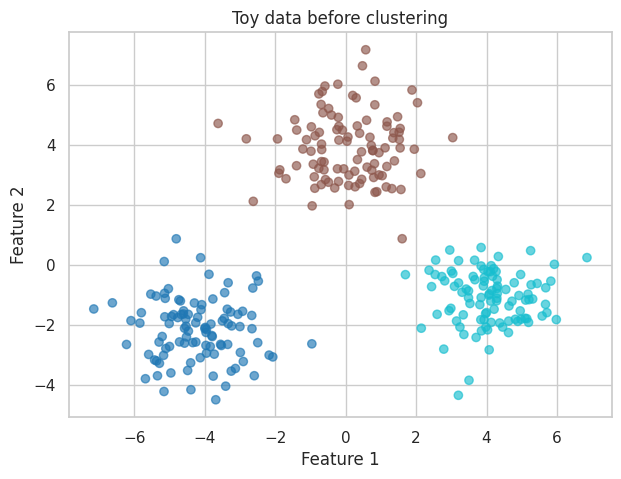

In [5]:
X_toy, true_group = make_blobs(
    n_samples=300,
    centers=[(-4, -2), (0, 4), (4, -1)],
    cluster_std=[1.0, 1.2, 0.9],
    random_state=12,
)

plt.figure(figsize=(7, 5))
plt.scatter(X_toy[:, 0], X_toy[:, 1], alpha=0.65, c=true_group, cmap="tab10",)
plt.title("Toy data before clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Predict before fitting

1. How many compact groups do you see?
- 3

2. Where would you place one initial centroid for each group?
- 3 random points from each group
- or 3 farthest points from each other

3. Would a different initialisation necessarily produce different final groups?
- yes, theoretically it can
- for example, when initial points visually belong to the same group

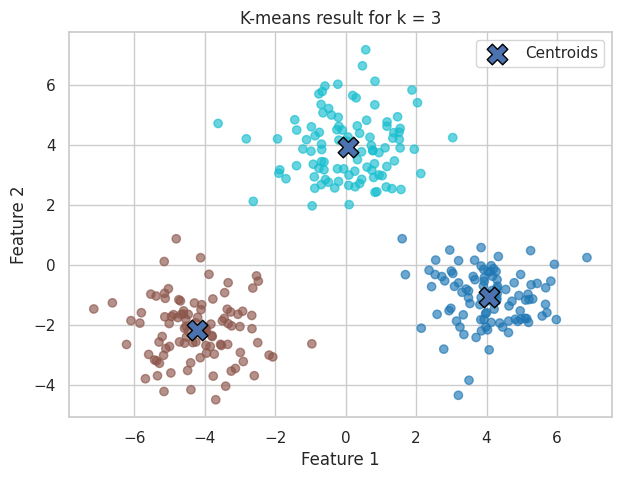

In [6]:
toy_model = KMeans(n_clusters=3, n_init=10, random_state=42)
toy_labels = toy_model.fit_predict(X_toy)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_toy[:, 0],
    X_toy[:, 1],
    # c = true_group,
    c=toy_labels,
    alpha=0.65,
    cmap="tab10",
)
plt.scatter(
    toy_model.cluster_centers_[:, 0],
    toy_model.cluster_centers_[:, 1],
    marker="X",
    s=220,
    edgecolor="black",
    label="Centroids",
)
plt.title("K-means result for k = 3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Activity 1 — Read the result

Answer briefly:

1. What does one centroid represent?
- the peak concentration of similarity

2. Why are the cluster identifiers `0`, `1`, and `2` not meaningful names?
- because 0, 1, and 2 are data, not information or knowledge, they don't give us any context and have no inherent meaning

3. Does K-means recover the original generator labels exactly?
- not exactly

4. Which visible property of these data makes K-means a reasonable method here?
- visually, the data naturally forms compact blobs of spherical-ish shape

### Cluster numbers may change without the partition changing

Fit the same model with a different random state. Compare the numeric labels and then compare the partitions using the **Adjusted Rand Index (ARI)**.

ARI compares two assignments while ignoring arbitrary permutations of cluster numbers:

- 1 means identical partitions,
- values near 0 indicate agreement similar to chance,
- negative values indicate worse-than-chance agreement.

In [7]:
toy_model_second = KMeans(n_clusters=3, n_init=10, random_state=7)
toy_labels_second = toy_model_second.fit_predict(X_toy)

comparison_labels = pd.DataFrame(
    {
        "first_run": toy_labels[:20],
        "second_run": toy_labels_second[:20],
    }
)

print("First 20 numeric labels")
display(comparison_labels)

print(
    "ARI between the two partitions:",
    adjusted_rand_score(toy_labels, toy_labels_second),
)

First 20 numeric labels


,first_run,second_run
0,0,2
1,2,0
2,2,0
3,1,1
4,2,0
5,0,2
6,1,1
7,1,1
8,1,1
9,1,1


ARI between the two partitions: 1.0


### Stop and explain

Why can the numeric labels differ even when ARI is close to 1?
- because labeling is purely random, but clustering is not

Write the interpretation without saying that “cluster 0 changed into cluster 2.” Focus on the **partition of points**, not on the arbitrary label names.
- the partition of points remained exactly the same, points that were grouped together in the first run stayed together in the second run

## 3. Selecting the number of clusters

K-means requires the number of clusters \(k\) in advance.

We will compare:

- **inertia** — the sum of squared distances from points to their assigned centroid; lower is better, but it always decreases as \(k\) grows,
- **silhouette score** — combines cohesion within clusters and separation from neighbouring clusters; higher is generally better.

Neither measure discovers the one objectively correct answer. They provide evidence that must be combined with visual inspection, stability, and interpretability.

In [8]:
toy_scores = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X_toy)

    toy_scores.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_toy, labels),
        }
    )

toy_scores = pd.DataFrame(toy_scores)
toy_scores

,k,inertia,silhouette
0,2,"2,687.958",0.566
1,3,639.766,0.723
2,4,554.538,0.589
3,5,482.064,0.449
4,6,419.745,0.320
5,7,364.886,0.333
6,8,316.587,0.335


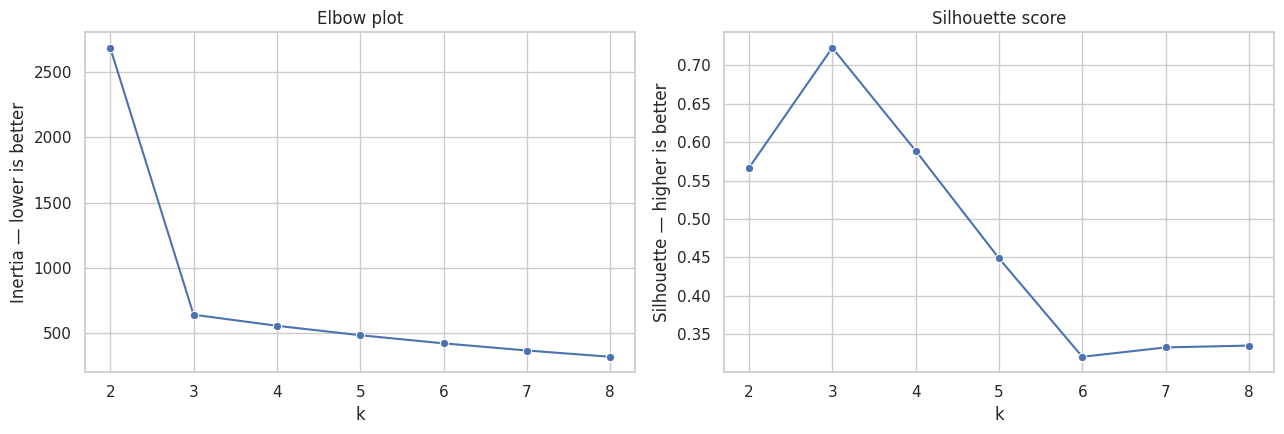

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=toy_scores,
    x="k",
    y="inertia",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Elbow plot")
axes[0].set_ylabel("Inertia — lower is better")

sns.lineplot(
    data=toy_scores,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Silhouette score")
axes[1].set_ylabel("Silhouette — higher is better")

plt.tight_layout()
plt.show()

### Activity 2 — Make and defend a choice

Choose one value of \(k\) and write a short evidence chain:

1. **Candidate:** I would choose \(k = 3\)
2. **Inertia evidence:** decrease to 639.766 was very fast, but then it is slower
3. **Silhouette evidence:** 0.723 is highest
4. **Visual evidence:** for inertia elbow is on 3 and for silhouette max is 3
5. **Limitation:** This choice is not automatically the “true” number of groups because ... we might not know all the real-life context of the domain

Then change `K_TO_INSPECT` below and inspect the corresponding partition.

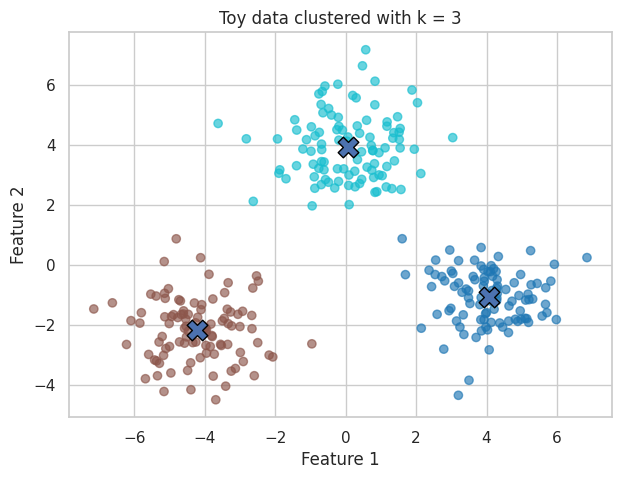

In [10]:
K_TO_INSPECT = 3  # Change this value after making your prediction.

model_to_inspect = KMeans(
    n_clusters=K_TO_INSPECT,
    n_init=10,
    random_state=42,
)
labels_to_inspect = model_to_inspect.fit_predict(X_toy)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_toy[:, 0],
    X_toy[:, 1],
    c=labels_to_inspect,
    alpha=0.65,
    cmap="tab10",
)
plt.scatter(
    model_to_inspect.cluster_centers_[:, 0],
    model_to_inspect.cluster_centers_[:, 1],
    marker="X",
    s=220,
    edgecolor="black",
)
plt.title(f"Toy data clustered with k = {K_TO_INSPECT}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 4. Scaling can change the clusters

We now multiply the second feature by 50. The points still describe the same artificial observations, but Euclidean distance will give the second axis much greater numerical influence.

### Predict before running

1. Will the unscaled K-means result remain similar?
- no, because the stretched feature will dominate the Euclidean distance

2. Will standardisation recover a geometry closer to the original one?
- yes

3. Which comparison would be stronger evidence: a visual plot or ARI against the known artificial groups?
- ARI against the known artificial groups

In [11]:
X_stretched = X_toy.copy()
X_stretched[:, 1] = X_stretched[:, 1] * 50

labels_stretched_raw = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42,
).fit_predict(X_stretched)

X_stretched_scaled = StandardScaler().fit_transform(X_stretched)

labels_stretched_scaled = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42,
).fit_predict(X_stretched_scaled)

scaling_comparison = pd.Series(
    {
        "ARI: original geometry vs known groups": adjusted_rand_score(
            true_group, toy_labels
        ),
        "ARI: stretched and not scaled": adjusted_rand_score(
            true_group, labels_stretched_raw
        ),
        "ARI: stretched and standardised": adjusted_rand_score(
            true_group, labels_stretched_scaled
        ),
    }
)

scaling_comparison

,0
ARI: original geometry vs known groups,0.990
ARI: stretched and not scaled,0.581
ARI: stretched and standardised,0.990


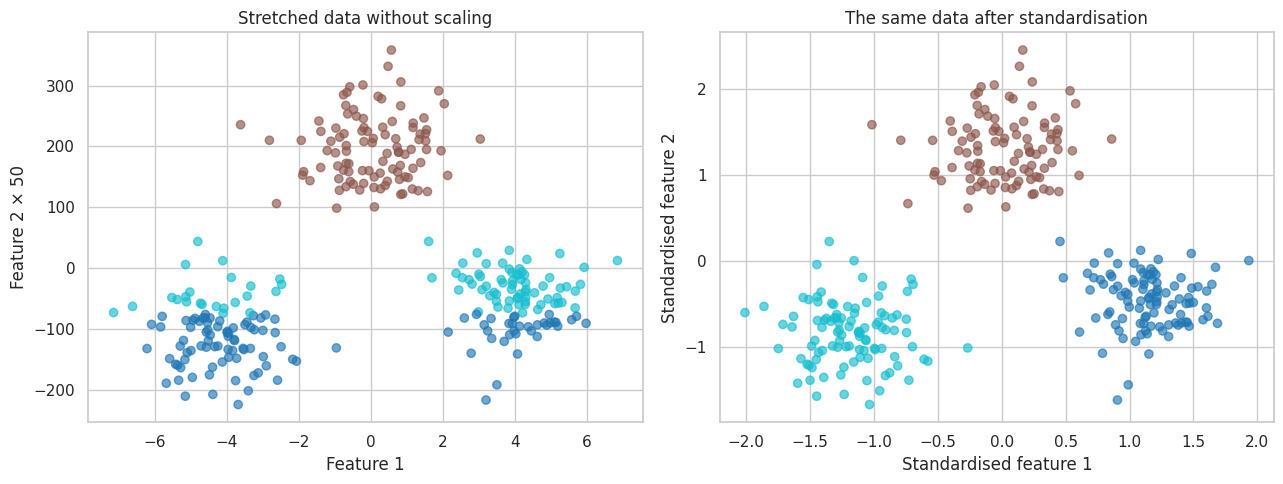

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    X_stretched[:, 0],
    X_stretched[:, 1],
    c=labels_stretched_raw,
    alpha=0.65,
    cmap="tab10",
)
axes[0].set_title("Stretched data without scaling")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2 × 50")

axes[1].scatter(
    X_stretched_scaled[:, 0],
    X_stretched_scaled[:, 1],
    c=labels_stretched_scaled,
    alpha=0.65,
    cmap="tab10",
)
axes[1].set_title("The same data after standardisation")
axes[1].set_xlabel("Standardised feature 1")
axes[1].set_ylabel("Standardised feature 2")

plt.tight_layout()
plt.show()

### Activity 3 — Explain the mechanism

Complete the argument:

> Multiplying one feature by 50 changed the clustering because Euclidean distance ... along the horizontal axis didn't change proportionally, so the horizontal distances between points now seem much shorter than the artificially inflated vertical distances.
>
> Standardisation changed the result because it ... rescaled both features to be comparable (mean 0, variance 1), restoring the original geometry so neither axis unfairly dominates the distance calculation.
>
> This experiment does not prove that every feature should always receive equal weight because ... in reality, some features are simply more important for determining similarity, and we might actually want to give them more weight based on domain knowledge.

## 5. Real-world clustering: Titanic passengers

We now cluster passengers using a small set of interpretable variables.

### Important modelling decision

`Survived` will **not** be used to create the clusters. We will keep it only as an external variable for later interpretation.

Before running the next cells, answer:

1. Why would including `Survived` partly build the later conclusion into the clusters?
- if we include it, the algorithm will just group survivors with survivors, creating a circular logic instead of finding natural profiles

2. Are we trying to predict survival here?
- no, we are just finding natural groups of passengers

3. What should one row and one distance represent?
- one row represents one passenger, and distance represents how similar two passengers are based on their features

**Dataset source:** Titanic passenger data used in the original course materials.

The cell first looks for `titanic.csv` locally and otherwise loads the course copy from GitHub.

In [13]:
TITANIC_URL = (
    "https://raw.githubusercontent.com/jplatos/VSB-FEI-Fundamentals-of-Machine-Learning/refs/heads/master/Datasets/titanic.csv"
)
LOCAL_TITANIC_PATH = Path("titanic.csv")

titanic_source = (
    LOCAL_TITANIC_PATH
    if LOCAL_TITANIC_PATH.exists()
    else TITANIC_URL
)

titanic_full = pd.read_csv(titanic_source)

print(f"Source: {titanic_source}")
print(
    f"Shape: {titanic_full.shape[0]} rows × "
    f"{titanic_full.shape[1]} columns"
)
titanic_full.head()

Source: https://raw.githubusercontent.com/jplatos/VSB-FEI-Fundamentals-of-Machine-Learning/refs/heads/master/Datasets/titanic.csv
Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


### Build a transparent analytical representation

We will use:

- numerical features: `Age`, `Fare`, `SibSp`, `Parch`,
- categorical features: `Sex`, `Embarked`, `Pclass`,
- external interpretation variable: `Survived`.

For this introductory exercise:

- missing numerical values are replaced by the median,
- missing categorical values are replaced by the most frequent category,
- `Fare` is transformed with `log1p` because of its long upper tail,
- numerical features are standardised,
- categorical features are one-hot encoded.

These are defensible starting choices, not universal rules.

In [14]:
feature_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Sex",
    "Embarked",
    "Pclass",
]
external_columns = ["Survived"]

titanic = titanic_full.loc[
    :,
    feature_columns + external_columns,
].copy()

titanic["Age"] = titanic["Age"].fillna(
    titanic["Age"].median()
)
titanic["Fare"] = titanic["Fare"].fillna(
    titanic["Fare"].median()
)
titanic["Embarked"] = titanic["Embarked"].fillna(
    titanic["Embarked"].mode().iloc[0]
)

titanic["Fare_log"] = np.log1p(titanic["Fare"])
titanic["FamilySize"] = (
    titanic["SibSp"] + titanic["Parch"] + 1
)

titanic.head()

,Age,Fare,SibSp,Parch,Sex,Embarked,Pclass,Survived,Fare_log,FamilySize
0,22.000,7.250,1,0,male,S,3,0,2.110,2
1,38.000,71.283,1,0,female,C,1,1,4.281,2
2,26.000,7.925,0,0,female,S,3,1,2.189,1
3,35.000,53.100,1,0,female,S,1,1,3.991,2
4,35.000,8.050,0,0,male,S,3,0,2.203,1


### Predict before preprocessing

1. Which raw numerical feature probably has the largest scale?
- fare

2. Why transform `Fare` before standardising it?
- to compress the long tail of extreme outliers so they don't distort the distribution after standardisation

3. Why treat `Pclass` as a category in this notebook even though it has an order?
- to avoid forcing equal mathematical distances, since the real-world gap between 1st and 2nd class is much larger than between 2nd and 3rd

4. What information is lost when we one-hot encode a genuinely ordered variable?
- the relative order itself, all categories become completely independent and equally distant from each other

In [16]:
numeric_features = [
    "Age",
    "Fare_log",
    "SibSp",
    "Parch",
]

numeric_scaler = StandardScaler()

X_numeric = pd.DataFrame(
    numeric_scaler.fit_transform(
        titanic[numeric_features]
    ),
    columns=numeric_features,
    index=titanic.index,
)

X_categorical = pd.get_dummies(
    titanic[["Sex", "Embarked", "Pclass"]].astype(str),
    prefix=["Sex", "Embarked", "Pclass"],
    dtype=float,
)

X_titanic = pd.concat(
    [X_numeric, X_categorical],
    axis=1,
)

print(
    f"Prepared matrix: {X_titanic.shape[0]} passengers × "
    f"{X_titanic.shape[1]} features"
)
X_titanic.head()

Prepared matrix: 891 passengers × 12 features


,Age,Fare_log,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,-0.566,-0.880,0.433,-0.474,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000
1,0.664,1.361,0.433,-0.474,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
2,-0.258,-0.799,-0.475,-0.474,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
3,0.433,1.062,0.433,-0.474,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000
4,0.433,-0.784,-0.475,-0.474,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000


### Verification checkpoint

Use the outputs below to check whether:

- numerical columns are centred near zero,
- dummy columns contain only 0 and 1,
- `Survived` is absent from the clustering matrix.

In [20]:
display(
    X_titanic[numeric_features]
    .agg(["mean", "std", "min", "max"])
)

display(
    X_titanic.drop(columns=numeric_features)
    .apply(lambda column: sorted(column.unique()))
)

print(
    "Survived in clustering matrix:",
    "Survived" in X_titanic.columns,
)

,Age,Fare_log,SibSp,Parch
mean,0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001
min,-2.224,-3.059,-0.475,-0.474
max,3.892,3.385,6.784,6.974


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


Survived in clustering matrix: False


## 6. Evaluate candidate values of k

We will inspect \(k = 2, \ldots, 8\).

Before running the cell, predict:

1. Do you expect one sharp, unambiguous optimum?
- No, real-world data is usually messy and rarely shows a single perfect optimum.

2. Would the largest silhouette score automatically guarantee useful passenger profiles?
- Not necessarily. The highest score means the clusters are mathematically well-separated, but they might lack real-world meaning. There can also be multiple similar scores.

3. Why should very small clusters be inspected carefully?
- Because they might just be capturing noise or a few outliers (anomalies) rather than representing a meaningful, generalizable segment of passengers.

In [23]:
titanic_scores = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42,
    )
    labels = model.fit_predict(X_titanic)

    cluster_sizes = pd.Series(labels).value_counts()

    titanic_scores.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(
                X_titanic,
                labels,
            ),
            "smallest_cluster": cluster_sizes.min(),
        }
    )

titanic_scores = pd.DataFrame(titanic_scores)
titanic_scores

,k,inertia,silhouette,smallest_cluster
0,2,"3,780.578",0.297,294
1,3,"2,999.758",0.281,134
2,4,"2,619.147",0.298,44
3,5,"2,381.580",0.251,44
4,6,"2,178.494",0.248,44
5,7,"2,002.595",0.254,12
6,8,"1,873.810",0.262,23


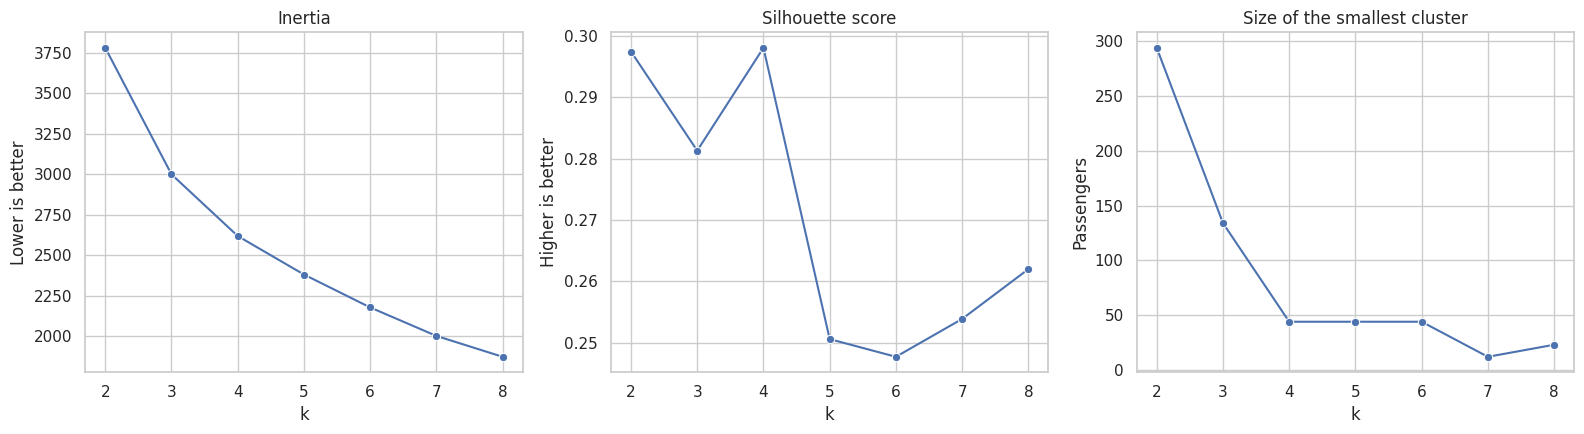

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.lineplot(
    data=titanic_scores,
    x="k",
    y="inertia",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Inertia")
axes[0].set_ylabel("Lower is better")

sns.lineplot(
    data=titanic_scores,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Silhouette score")
axes[1].set_ylabel("Higher is better")

sns.lineplot(
    data=titanic_scores,
    x="k",
    y="smallest_cluster",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Size of the smallest cluster")
axes[2].set_ylabel("Passengers")

plt.tight_layout()
plt.show()

### Activity 4 — Select a defensible candidate

Write a short argument for one candidate \(k\). Your argument must mention:

- the elbow or rate of inertia reduction,
- the silhouette score,
- the size of the smallest cluster,
- the need to inspect whether the resulting profiles are understandable.

The notebook uses `SELECTED_K = 3` as a common classroom starting point. You may change it after examining the evidence.

**My Answer:**

I would select k = 4 for the following reasons:
* **Inertia:** There is a steep drop up to this point, after which the rate of reduction slows down noticeably (the "elbow" rule).
* **Silhouette score:** It reaches its maximum at k=4, which serves as a second confirmation.
* **Size of the smallest cluster:** It stops changing significantly after k=4. This indicates that the groups at this point are likely natural, whereas increasing k further mainly causes the algorithm to isolate outliers.
* **Profile understandability:** Good mathematical metrics are not enough, we must inspect whether the resulting 4 profiles actually make real-world sense and can be logically described, rather than just being mathematical artifacts.

In [28]:
SELECTED_K = 4

titanic_model = KMeans(
    n_clusters=SELECTED_K,
    n_init=20,
    random_state=42,
)
titanic_labels = titanic_model.fit_predict(X_titanic)

titanic_result = titanic.copy()
titanic_result["cluster"] = titanic_labels

titanic_result["cluster"].value_counts().sort_index()

,count
cluster,
0,116
1,253
2,44
3,478


## 7. Interpret clusters in the original units

Centroids live in the prepared feature space. Human interpretation is usually easier in the original variables.

The profile below reports:

- cluster size,
- median age and fare,
- mean family size,
- proportion of women,
- proportion of first-class passengers,
- survival rate as an **external descriptive variable**.

A high survival rate does not mean that the cluster caused survival.

In [ ]:
cluster_profile = (
    titanic_result
    .groupby("cluster")
    .agg(
        passengers=("cluster", "size"),
        median_age=("Age", "median"),
        median_fare=("Fare", "median"),
        mean_family_size=("FamilySize", "mean"),
        female_share=(
            "Sex",
            lambda values: (values == "female").mean(),
        ),
        first_class_share=(
            "Pclass",
            lambda values: (values == 1).mean(),
        ),
        survival_rate=("Survived", "mean"),
    )
)

cluster_profile["share_of_dataset"] = (
    cluster_profile["passengers"] / len(titanic_result)
)

cluster_profile = cluster_profile[
    [
        "passengers",
        "share_of_dataset",
        "median_age",
        "median_fare",
        "mean_family_size",
        "female_share",
        "first_class_share",
        "survival_rate",
    ]
]

cluster_profile

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=titanic_result,
    x="cluster",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Cluster sizes")

sns.boxplot(
    data=titanic_result,
    x="cluster",
    y="Age",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Age by cluster")

sns.boxplot(
    data=titanic_result,
    x="cluster",
    y="Fare",
    showfliers=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Fare by cluster — outliers hidden for readability")

survival_by_cluster = (
    titanic_result
    .groupby("cluster")["Survived"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=survival_by_cluster,
    x="cluster",
    y="Survived",
    ax=axes[1, 1],
)
axes[1, 1].set_title("External comparison: survival rate")
axes[1, 1].set_ylabel("Proportion who survived")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Activity 5 — Name clusters cautiously

For each cluster, write **two or three sentences**.

Use this structure:

> Cluster ... contains ... passengers. Compared with the full dataset, it has a higher/lower ... and a typical ... of .... A cautious descriptive name could be “...”, although the cluster also contains exceptions.

Rules:

- support every description with at least two values from the profile,
- do not use the arbitrary number as the meaning,
- avoid causal statements,
- mention at least one within-cluster variation or limitation.

### Guided AI study activity — improve an interpretation through questions

First, write your own interpretation of **one** cluster.

Then use this prompt:

```text
I am learning to interpret K-means clusters.
I will paste my own short interpretation and a table of cluster statistics.

Do not rewrite my answer and do not give me a model answer.
Ask me exactly three short questions, one at a time:

1. Which numerical evidence supports the descriptive label?
2. Which important within-cluster variation or exception did I ignore?
3. Did I accidentally make a causal claim from a descriptive cluster?

After the third answer, ask me to close the chat and revise the interpretation myself.
```

After closing the chat, revise the interpretation in your notebook.

Finally, record only:

- one question that exposed a weakness,
- one sentence you changed,
- why the revised version is more defensible.

Do **not** paste the full chat transcript.

## 8. Is the solution stable?

A result that changes strongly with random initialisation should be interpreted cautiously.

We compare ten runs with the same \(k\). The first run is the reference. ARI compares each later partition with it.

In [ ]:
stability_labels = []

for seed in range(10):
    model = KMeans(
        n_clusters=SELECTED_K,
        n_init=1,
        random_state=seed,
    )
    stability_labels.append(
        model.fit_predict(X_titanic)
    )

reference_labels = stability_labels[0]

stability = pd.DataFrame(
    {
        "seed": range(10),
        "ARI_vs_seed_0": [
            adjusted_rand_score(
                reference_labels,
                labels,
            )
            for labels in stability_labels
        ],
    }
)

stability

In [ ]:
sns.lineplot(
    data=stability,
    x="seed",
    y="ARI_vs_seed_0",
    marker="o",
)
plt.ylim(-0.05, 1.05)
plt.title(
    f"Stability across initialisations for k = {SELECTED_K}"
)
plt.ylabel("ARI compared with seed 0")
plt.show()

### Activity 6 — Interpret stability

1. Is the solution identical across all initialisations?
2. Would increasing `n_init` make the final run more reliable? Why?
3. Does high stability prove that the clusters are useful?
4. Does lower stability automatically mean that the data contain no structure?

## 9. Transfer task — Country data

This final task prepares you for the first part of the semester project.

Each row represents a country and the variables describe health, demographic, and economic indicators.

Your goal is not to produce the most impressive plot. Your goal is to construct and defend a complete analytical chain:

> **representation → scaling → choice of k → profiles → interpretation → limitation**

In [ ]:
COUNTRY_URL = (
    "https://raw.githubusercontent.com/rasvob/"
    "VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/"
    "master/datasets/country-data.csv"
)
LOCAL_COUNTRY_PATH = Path("country-data.csv")

country_source = (
    LOCAL_COUNTRY_PATH
    if LOCAL_COUNTRY_PATH.exists()
    else COUNTRY_URL
)

countries = pd.read_csv(country_source)

print(f"Source: {country_source}")
print(
    f"Shape: {countries.shape[0]} rows × "
    f"{countries.shape[1]} columns"
)
countries.head()

### Final task

Use the prepared framework below.

1. Inspect the variables and decide whether all numerical columns should enter the clustering.
2. Standardise the selected variables.
3. Evaluate \(k = 2, \ldots, 7\).
4. Choose `COUNTRY_K`.
5. Build a cluster profile in original units.
6. Describe every cluster.
7. Name one country that seems unusual within its cluster.
8. State one limitation of interpreting countries only from these indicators.

The code is intentionally almost complete. Your main work is the **decision and interpretation**, not writing a long program.

In [ ]:
country_numeric = countries.select_dtypes(include="number").copy()

country_scaler = StandardScaler()
X_country = country_scaler.fit_transform(country_numeric)

country_scores = []

for k in range(2, 8):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42,
    )
    labels = model.fit_predict(X_country)

    country_scores.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(
                X_country,
                labels,
            ),
            "smallest_cluster": pd.Series(
                labels
            ).value_counts().min(),
        }
    )

country_scores = pd.DataFrame(country_scores)
country_scores

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=country_scores,
    x="k",
    y="inertia",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Country data: inertia")

sns.lineplot(
    data=country_scores,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Country data: silhouette")

plt.tight_layout()
plt.show()

In [ ]:
COUNTRY_K = 3  # Change only after examining the evidence.

country_model = KMeans(
    n_clusters=COUNTRY_K,
    n_init=20,
    random_state=42,
)
country_labels = country_model.fit_predict(X_country)

country_result = countries.copy()
country_result["cluster"] = country_labels

country_profile = (
    country_result
    .groupby("cluster")
    .agg(
        countries=("country", "size"),
        child_mortality=("child_mort", "median"),
        exports=("exports", "median"),
        health=("health", "median"),
        income=("income", "median"),
        inflation=("inflation", "median"),
        life_expectancy=("life_expec", "median"),
        fertility=("total_fer", "median"),
        gdpp=("gdpp", "median"),
    )
)

country_profile

In [ ]:
# Inspect countries within one cluster at a time.
CLUSTER_TO_INSPECT = 0

country_result.loc[
    country_result["cluster"] == CLUSTER_TO_INSPECT
].sort_values("gdpp").head(20)

### Submission checkpoint

Your final Markdown response should contain:

1. the selected \(k\) and the evidence for it,
2. a concise description of every cluster,
3. at least two numerical values supporting each description,
4. one unusual country and the reason it deserves inspection,
5. one limitation of the representation,
6. one change you would test next.

### Project bridge

For your own semester dataset, write down:

- what one row represents,
- which columns should define similarity,
- which columns should be excluded from clustering,
- which features require scaling or transformation,
- how you will evaluate candidate values of \(k\),
- how you will interpret and verify the resulting clusters.

## Summary

The central lessons of this exercise are:

- K-means operates on a chosen numerical representation, not directly on real-world meaning.
- Scaling can change the geometry and therefore the clusters.
- Inertia always improves as \(k\) grows; the silhouette score is useful but not decisive.
- Cluster numbers are arbitrary identifiers.
- A cluster must be interpreted in the original variables and with evidence.
- External variables may help describe clusters, but they should not silently define them.
- Stability is evidence about reproducibility, not proof of usefulness.
- AI is most valuable here when it questions an interpretation that you wrote first.